In [3]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import logging

import argparse
import dataclasses
import xarray as xr
import numpy as np
import pandas as pd
from datetime import datetime
from tqdm import tqdm
import imdlib as imd
import xesmf as xe

import jax
import optax

from graphcast import checkpoint, data_utils, rollout, graphcast, normalization
import save_params_utils
import setup_jax_functions
from plotting import scale, select, plot_data, save_animation, save_static_plot
from metrics import compute_rmse, compute_mae, compute_bias, compute_acc
from utils import generate_sample_era5_dataset, grads_fn
import matplotlib.pyplot as plt
# import pynvml
import time

current_date = datetime.now().strftime("%Y-%m-%d_%H-%M")

# jax.config.update('jax_disable_jit', True)

# for memory efficiency
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE']='false'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '2.0' 
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"

mean_by_level = None
stddev_by_level = None
diffs_stddev_by_level = None
model_config = None
task_config = None
params = None
state = None
latmax = 38
latmin = 6
lonmin = 68
lonmax = 98

In [4]:
predictions_old = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_old_india2015_jan20160.nc")
predictions_finetuned = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_finetuned_india2015_full_jan20160.nc")

/tmp/ipykernel_1969170/752260235.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  predictions_old = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_old_india2015_jan20160.nc")
/tmp/ipykernel_1969170/752260235.py:2: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  predictions_finetuned = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_finetuned_india2015_full_jan20160.nc")


In [5]:
predictions_old

<xarray.Dataset> Size: 1GB
Dimensions:                  (time: 28, batch: 1, lat: 181, lon: 360, level: 13)
Coordinates:
  * time                     (time) timedelta64[ns] 224B 0 days 06:00:00 ... ...
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
  * lat                      (lat) float64 1kB 90.0 89.0 88.0 ... -89.0 -90.0
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
Dimensions without coordinates: batch
Data variables:
    10m_u_component_of_wind  (time, batch, lat, lon) float64 15MB ...
    10m_v_component_of_wind  (time, batch, lat, lon) float64 15MB ...
    2m_temperature           (time, batch, lat, lon) float64 15MB ...
    geopotential             (time, batch, level, lat, lon) float64 190MB ...
    mean_sea_level_pressure  (time, batch, lat, lon) float64 15MB ...
    specific_humidity        (time, batch, level, lat, lon) float64 190MB ...
    temperature              (time, batch, level, lat, lon) float64 190MB ...
    total_precipitation_6hr  (time, batch, lat, lon) float64 15MB ...
    u_component_of_wind      (time, batch, level, lat, lon) float64 190MB ...
    v_component_of_wind      (time, batch, level, lat, lon) float64 190MB ...
    vertical_velocity        (time, batch, level, lat, lon) float64 190MB ...

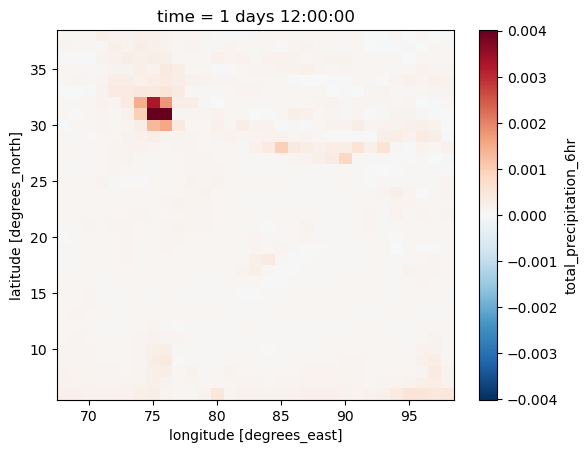

In [6]:
# over India
predictions_old.isel(time=5)['total_precipitation_6hr'].sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).plot()

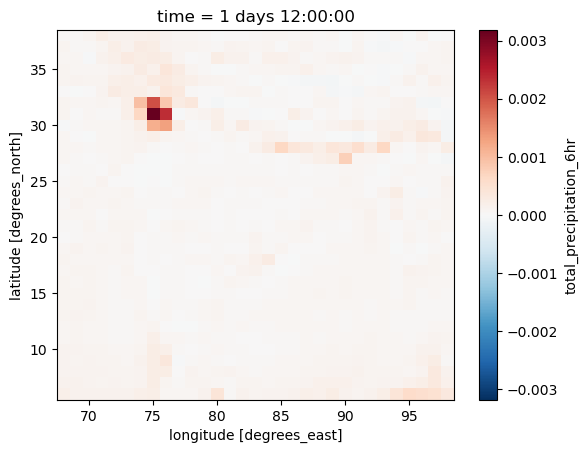

In [7]:
predictions_finetuned.isel(time=5)['total_precipitation_6hr'].sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).plot()

In [8]:
print(f"Number of days predicted: {len(predictions_finetuned.time.values)/4}")

Number of days predicted: 7.0


In [9]:
start_yr = 2016
end_yr = 2016
variable = 'rain' # other options are ('tmin'/ 'tmax')
file_dir = "/Datastorage/saptarishi.dhanuka_asp25/imdlib_data/raw_imdlib"
data = imd.open_data(variable, start_yr, end_yr, 'yearwise', file_dir+'/rain/')
ds = data.get_xarray()
ds

<xarray.Dataset> Size: 51MB
Dimensions:  (time: 366, lat: 129, lon: 135)
Coordinates:
  * lat      (lat) float64 1kB 6.5 6.75 7.0 7.25 7.5 ... 37.75 38.0 38.25 38.5
  * lon      (lon) float64 1kB 66.5 66.75 67.0 67.25 ... 99.25 99.5 99.75 100.0
  * time     (time) datetime64[ns] 3kB 2016-01-01 2016-01-02 ... 2016-12-31
Data variables:
    rain     (time, lat, lon) float64 51MB -999.0 -999.0 ... -999.0 -999.0
Attributes:
    Conventions:  CF-1.7
    title:        IMD gridded data
    source:       https://imdpune.gov.in/
    history:      2025-06-06 17:39:09.463029 Python
    references:   
    comment:      
    crs:          epsg:4326

In [10]:
ds_jan2016 = ds.sel(time=slice('2016-01-01', '2016-01-31'))
ds_jan2016 = ds_jan2016.where(ds_jan2016 ['rain'] != -999.)
ds_jan2016

<xarray.Dataset> Size: 4MB
Dimensions:  (time: 31, lat: 129, lon: 135)
Coordinates:
  * lat      (lat) float64 1kB 6.5 6.75 7.0 7.25 7.5 ... 37.75 38.0 38.25 38.5
  * lon      (lon) float64 1kB 66.5 66.75 67.0 67.25 ... 99.25 99.5 99.75 100.0
  * time     (time) datetime64[ns] 248B 2016-01-01 2016-01-02 ... 2016-01-31
Data variables:
    rain     (time, lat, lon) float64 4MB nan nan nan nan ... nan nan nan nan
Attributes:
    Conventions:  CF-1.7
    title:        IMD gridded data
    source:       https://imdpune.gov.in/
    history:      2025-06-06 17:39:09.463029 Python
    references:   
    comment:      
    crs:          epsg:4326

In [11]:
ds_jan_lat_rev = ds_jan2016.isel(lat=slice(None, None, -1))

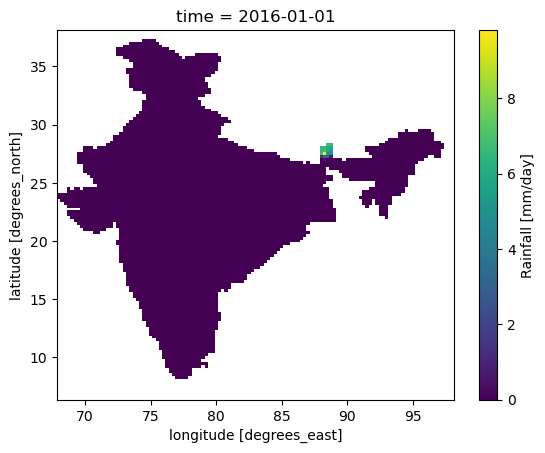

In [37]:
ds_jan_lat_rev.isel(time=0)['rain'].sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).plot()

In [13]:
predictions_old_daily_temp = predictions_old.resample(time='1D').sum()
predictions_old_daily = predictions_old_daily_temp * 1000 # convert from m to mm
predictions_old_daily.attrs["ppt units"] = "mm/day"
predictions_old_daily

<xarray.Dataset> Size: 303MB
Dimensions:                  (level: 13, lat: 181, lon: 360, time: 7, batch: 1)
Coordinates:
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
  * lat                      (lat) float64 1kB 90.0 89.0 88.0 ... -89.0 -90.0
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
  * time                     (time) timedelta64[ns] 56B 0 days 06:00:00 ... 6...
Dimensions without coordinates: batch
Data variables:
    10m_u_component_of_wind  (time, batch, lat, lon) float64 4MB -4.418e+03 ....
    10m_v_component_of_wind  (time, batch, lat, lon) float64 4MB -1.879e+03 ....
    2m_temperature           (time, batch, lat, lon) float64 4MB 1.001e+06 .....
    geopotential             (time, batch, level, lat, lon) float64 47MB 7.53...
    mean_sea_level_pressure  (time, batch, lat, lon) float64 4MB 4.173e+08 .....
    specific_humidity        (time, batch, level, lat, lon) float64 47MB 0.00...
    temperature              (time, batch, level, lat, lon) float64 47MB 7.58...
    total_precipitation_6hr  (time, batch, lat, lon) float64 4MB -0.4306 ... ...
    u_component_of_wind      (time, batch, level, lat, lon) float64 47MB -4.0...
    v_component_of_wind      (time, batch, level, lat, lon) float64 47MB -4.7...
    vertical_velocity        (time, batch, level, lat, lon) float64 47MB 5.84...
Attributes:
    ppt units:  mm/day

In [47]:
predictions_finetuned_daily_temp = predictions_finetuned.resample(time='1D').sum()
predictions_finetuned_daily = predictions_finetuned_daily_temp * 1000 # convert from m to mm
predictions_finetuned_daily.attrs["ppt units"] = "mm/day"
predictions_finetuned_daily

<xarray.Dataset> Size: 303MB
Dimensions:                  (level: 13, lat: 181, lon: 360, time: 7, batch: 1)
Coordinates:
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
  * lat                      (lat) float64 1kB 90.0 89.0 88.0 ... -89.0 -90.0
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
  * time                     (time) timedelta64[ns] 56B 0 days 06:00:00 ... 6...
Dimensions without coordinates: batch
Data variables:
    10m_u_component_of_wind  (time, batch, lat, lon) float64 4MB -4.98e+03 .....
    10m_v_component_of_wind  (time, batch, lat, lon) float64 4MB -1.609e+03 ....
    2m_temperature           (time, batch, lat, lon) float64 4MB 1e+06 ... 9....
    geopotential             (time, batch, level, lat, lon) float64 47MB 7.53...
    mean_sea_level_pressure  (time, batch, lat, lon) float64 4MB 4.174e+08 .....
    specific_humidity        (time, batch, level, lat, lon) float64 47MB 0.00...
    temperature              (time, batch, level, lat, lon) float64 47MB 7.57...
    total_precipitation_6hr  (time, batch, lat, lon) float64 4MB -0.4329 ... ...
    u_component_of_wind      (time, batch, level, lat, lon) float64 47MB -2.8...
    v_component_of_wind      (time, batch, level, lat, lon) float64 47MB -3.1...
    vertical_velocity        (time, batch, level, lat, lon) float64 47MB 2.88...
Attributes:
    ppt units:  mm/day

In [14]:
for i in range(0, len(predictions_old_daily.time.values)):
    print(predictions_old_daily.isel(time=i)['total_precipitation_6hr'].sum().item())
    print(predictions_old.isel(time=slice(i,i+4))['total_precipitation_6hr'].sum().item())
    print("====")

163342.98057942282
163.34298057942286
====
162291.34052516686
165.71913113200225
====
168264.85150831356
163.24160886479712
====
166115.50043403034
162.24462229895528
====
163520.0996870212
162.29134052516687
====
166156.15807538814
163.01046230186643
====
165981.2128580964
164.08131543551806
====


In [15]:
print(ds_jan_lat_rev['rain'])

<xarray.DataArray 'rain' (time: 31, lat: 129, lon: 135)> Size: 4MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, na

In [16]:
print(predictions_old_daily['total_precipitation_6hr'])

<xarray.DataArray 'total_precipitation_6hr' (time: 7, batch: 1, lat: 181,
                                             lon: 360)> Size: 4MB
array([[[[-0.43061057, -0.46146564, -0.42504274, ..., -0.44708208,
          -0.45056197, -0.45172194],
         [-0.18269518, -0.1774519 , -0.18626763, ..., -0.16443696,
          -0.16316894, -0.16761563],
         [ 0.07569842,  0.0845376 ,  0.0852879 , ...,  0.08065528,
           0.11902728,  0.08797856],
         ...,
         [-0.06982989, -0.08896931, -0.06542202, ..., -0.07562971,
          -0.05138645, -0.06704597],
         [ 0.1755027 ,  0.1688909 ,  0.18826231, ...,  0.1292201 ,
           0.15427534,  0.16935488],
         [ 0.2549603 ,  0.26400802,  0.26354404, ...,  0.23060103,
           0.24104072,  0.2382568 ]]],


       [[[-0.10367445, -0.17054643, -0.13226759, ..., -0.18214608,
          -0.15639486, -0.14955107],
         [ 0.21099693,  0.1733215 ,  0.20440856, ...,  0.22206336,
           0.20894782,  0.21006895],
         [

In [17]:
print(predictions_old.isel(time=slice(0,4))['total_precipitation_6hr'].sum())

<xarray.DataArray 'total_precipitation_6hr' ()> Size: 8B
array(163.34298058)


In [18]:
print(predictions_old_daily.isel(time=0)["total_precipitation_6hr"].sum())

<xarray.DataArray 'total_precipitation_6hr' ()> Size: 8B
array(163342.98057942)
Coordinates:
    time     timedelta64[ns] 8B 06:00:00


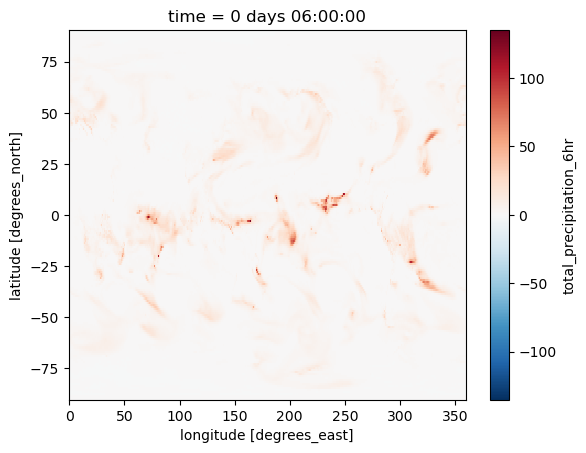

In [19]:
predictions_old_daily.isel(time=0)["total_precipitation_6hr"].plot()

In [20]:
diff = predictions_old_daily.isel(time=0)["total_precipitation_6hr"] - ds_jan_lat_rev.isel(time=0)['rain']

In [22]:
ds_jan_lat_rev

<xarray.Dataset> Size: 4MB
Dimensions:  (time: 31, lat: 129, lon: 135)
Coordinates:
  * lat      (lat) float64 1kB 38.5 38.25 38.0 37.75 37.5 ... 7.25 7.0 6.75 6.5
  * lon      (lon) float64 1kB 66.5 66.75 67.0 67.25 ... 99.25 99.5 99.75 100.0
  * time     (time) datetime64[ns] 248B 2016-01-01 2016-01-02 ... 2016-01-31
Data variables:
    rain     (time, lat, lon) float64 4MB nan nan nan nan ... nan nan nan nan
Attributes:
    Conventions:  CF-1.7
    title:        IMD gridded data
    source:       https://imdpune.gov.in/
    history:      2025-06-06 17:39:09.463029 Python
    references:   
    comment:      
    crs:          epsg:4326

In [21]:
regridder = xe.Regridder(ds_jan_lat_rev, predictions_old_daily, "conservative")
regridder

/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


xESMF Regridder 
Regridding algorithm:       conservative 
Weight filename:            conservative_129x135_181x360.nc 
Reuse pre-computed weights? False 
Input grid shape:           (129, 135) 
Output grid shape:          (181, 360) 
Periodic in longitude?      False

In [23]:
dr_out = regridder(ds_jan_lat_rev, keep_attrs=True)
dr_out

/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


<xarray.Dataset> Size: 16MB
Dimensions:  (time: 31, lat: 181, lon: 360)
Coordinates:
  * time     (time) datetime64[ns] 248B 2016-01-01 2016-01-02 ... 2016-01-31
  * lat      (lat) float64 1kB 90.0 89.0 88.0 87.0 ... -87.0 -88.0 -89.0 -90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Data variables:
    rain     (time, lat, lon) float64 16MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    Conventions:    CF-1.7
    title:          IMD gridded data
    source:         https://imdpune.gov.in/
    history:        2025-06-06 17:39:09.463029 Python
    references:     
    comment:        
    crs:            epsg:4326
    regrid_method:  conservative

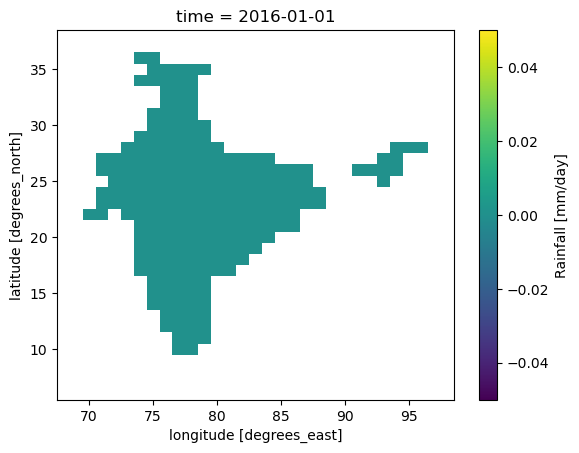

In [46]:
dr_out.isel(time=0)["rain"].sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).plot()

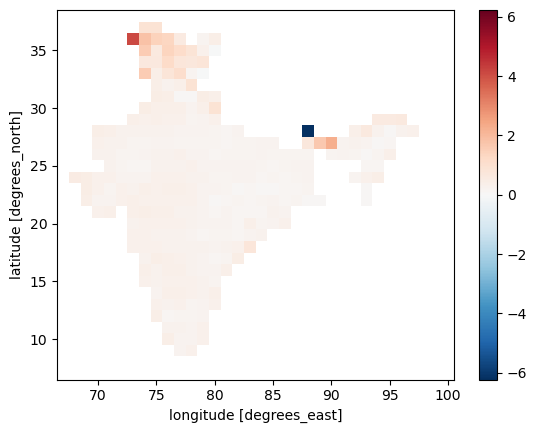

In [48]:
diff.plot()

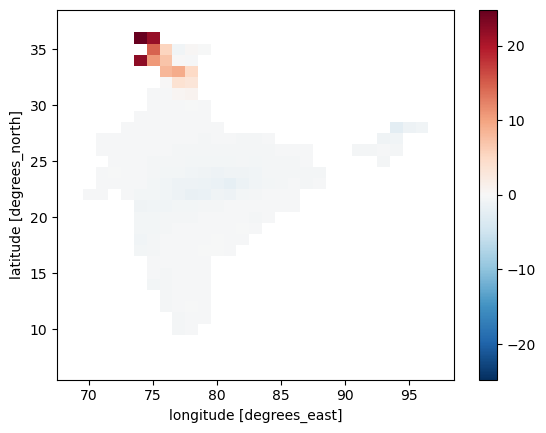

In [59]:
diff1 = dr_out.isel(time=4)["rain"].sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)) - predictions_old_daily.isel(time=4)["total_precipitation_6hr"].sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax))
diff1.plot()

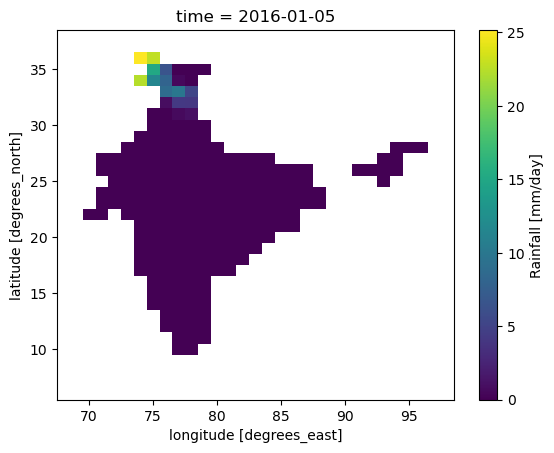

In [57]:
dr_out.isel(time=4)["rain"].sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).plot()

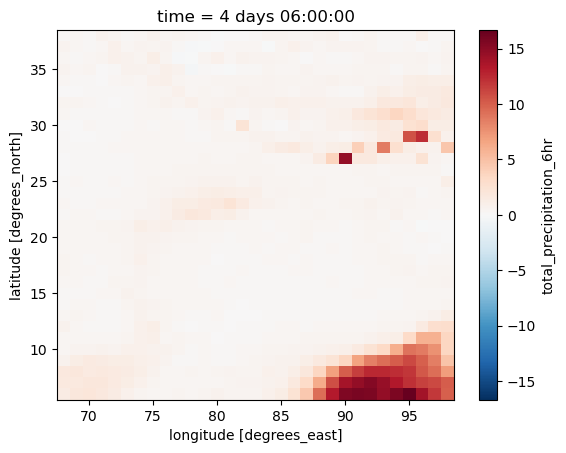

In [58]:
predictions_old_daily.isel(time=4)["total_precipitation_6hr"].sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).plot()